In [2]:
import kagglehub
path = kagglehub.dataset_download("snap/amazon-fine-food-reviews")

Using Colab cache for faster access to the 'amazon-fine-food-reviews' dataset.


In [3]:
import pandas as pd
df = pd.read_csv(path + "/Reviews.csv")
df.head()

,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text
0,1,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1,1,5,1303862400,Good Quality Dog Food,I have bought several of the Vitality canned d...
1,2,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0,0,1,1346976000,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...
2,3,B000LQOCH0,ABXLMWJIXXAIN,"Natalia Corres ""Natalia Corres""",1,1,4,1219017600,"""Delight"" says it all",This is a confection that has been around a fe...
3,4,B000UA0QIQ,A395BORC6FGVXV,Karl,3,3,2,1307923200,Cough Medicine,If you are looking for the secret ingredient i...
4,5,B006K2ZZ7K,A1UQRSCLF8GW1T,"Michael D. Bigham ""M. Wassir""",0,0,5,1350777600,Great taffy,Great taffy at a great price. There was a wid...


# Filters & Create Sentiments

In [6]:
from IPython.display import display
# Take a manageable sample of 5000 reviews
df_sample = df.sample(n=5000, random_state=42).copy()
def map_sentiment(stars):
    if stars >=4:
        return 'positive'
    elif stars == 3:
        return 'neutral'
    else:
        return 'negative'

df_sample['Sentiment'] = df_sample['Score'].apply(map_sentiment)
print(df_sample[['Text', 'Sentiment']].head())

                                                     Text Sentiment
165256  Having tried a couple of other brands of glute...  positive
231465  My cat loves these treats. If ever I can't fin...  positive
427827  A little less than I expected.  It tends to ha...   neutral
433954  First there was Frosted Mini-Wheats, in origin...  negative
70260   and I want to congratulate the graphic artist ...  positive


# Clean and Preprocess Review Text Data

In [9]:
import re
def clean_review_text(raw_text):
    # Keep only normal letters and Spaces
    cleaned = re.sub(r'[^a-zA-Z\s]', '', str(raw_text))
    # Convert everthing to lowercase
    return cleaned.lower().strip()

#Apply cleaning functions to the 'Text' column
df_sample['Cleaned_Text'] = df_sample['Text'].apply(clean_review_text)
print(df_sample[['Text', 'Cleaned_Text']].head())

                                                     Text  \
165256  Having tried a couple of other brands of glute...   
231465  My cat loves these treats. If ever I can't fin...   
427827  A little less than I expected.  It tends to ha...   
433954  First there was Frosted Mini-Wheats, in origin...   
70260   and I want to congratulate the graphic artist ...   

                                             Cleaned_Text  
165256  having tried a couple of other brands of glute...  
231465  my cat loves these treats if ever i cant find ...  
427827  a little less than i expected  it tends to hav...  
433954  first there was frosted miniwheats in original...  
70260   and i want to congratulate the graphic artist ...  


# Visualize Sentiment Distribution and Trends

/tmp/ipykernel_2134/2696215199.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_sample, x='Sentiment', order=['positive', 'neutral', 'negative'], palette='pastel')


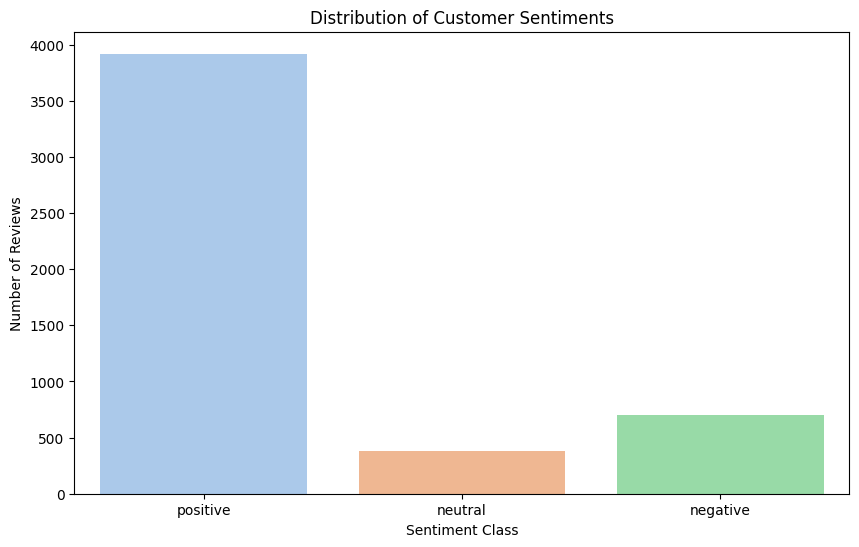

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(10,6))
sns.countplot(data=df_sample, x='Sentiment', order=['positive', 'neutral', 'negative'], palette='pastel')
plt.title('Distribution of Customer Sentiments')
plt.xlabel('Sentiment Class')
plt.ylabel('Number of Reviews')
plt.show()

# Machine Learning Feature Extractions & Training

In [11]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

# 1. Convert text words into numerical features
vectorizer = TfidfVectorizer(max_features=2500)
X = vectorizer.fit_transform(df_sample['Cleaned_Text']).toarray()
y = df_sample['Sentiment']

# 2. Train/Test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Train the Sentiment Model
sentiment_model = LogisticRegression(max_iter=1000)
sentiment_model.fit(X_train, y_train)

# 4. Generate the report card
y_pred = sentiment_model.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

    negative       0.81      0.32      0.45       133
     neutral       0.20      0.01      0.03        73
    positive       0.83      0.99      0.91       794

    accuracy                           0.83      1000
   macro avg       0.61      0.44      0.46      1000
weighted avg       0.78      0.83      0.78      1000

